In [88]:
print("""
DevRise AI & ML Internship – Task 2
Iris Flower Classification using Machine Learning

Name: Kanishk Singh

Objective:
Build and evaluate multiple Machine Learning classification models on the Iris dataset and compare their performance using various evaluation metrics.
""")



DevRise AI & ML Internship – Task 2
Iris Flower Classification using Machine Learning

Name: Kanishk Singh

Objective:
Build and evaluate multiple Machine Learning classification models on the Iris dataset and compare their performance using various evaluation metrics.



In [89]:
## Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from matplotlib.colors import ListedColormap

# Plot Style
plt.style.use("ggplot")

In [90]:
## 📂 Load Dataset
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target

In [91]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [93]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [94]:
df.shape

(150, 5)

In [95]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

In [96]:
df.duplicated().sum()

np.int64(1)

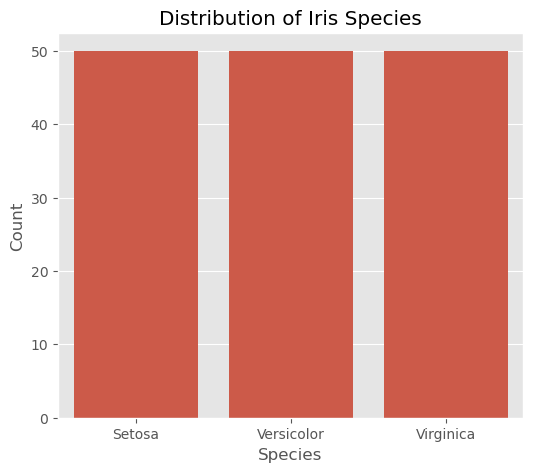

In [97]:
## 📊 Exploratory Data Analysis

species_names = {
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
}

df["species_name"] = df["species"].map(species_names)

df.head()

plt.figure(figsize=(6, 5))

sns.countplot(x="species_name", data=df)

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.savefig("images/Countplot.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1200x800 with 0 Axes>

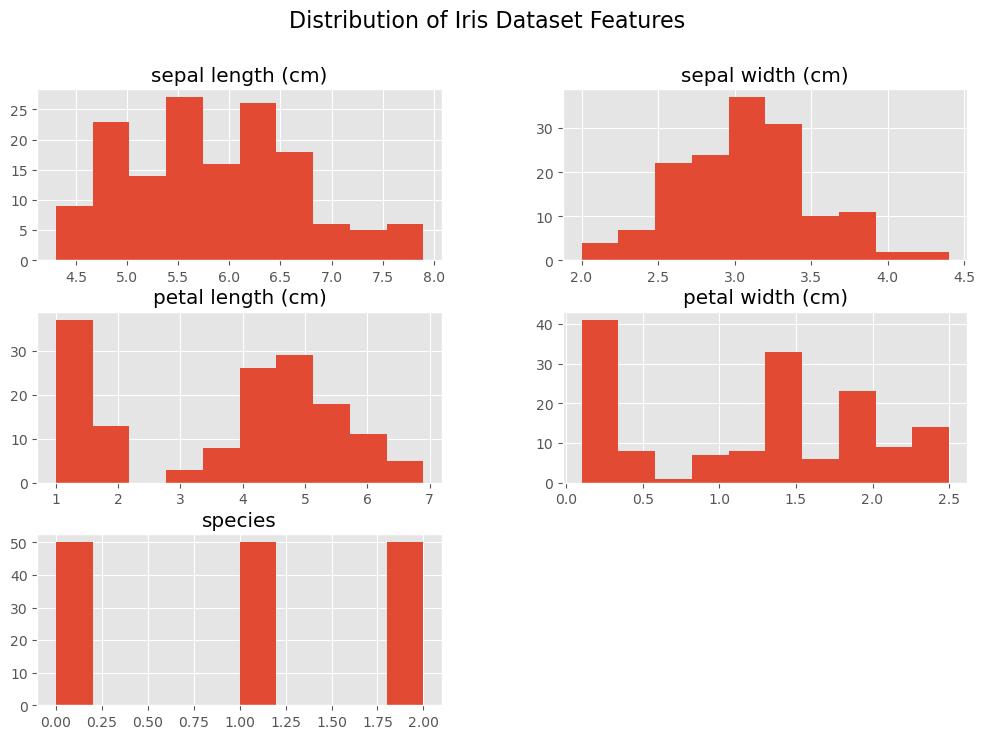

In [98]:
plt.figure(figsize=(12, 8))

df.hist(figsize=(12, 8))

plt.suptitle("Distribution of Iris Dataset Features", fontsize=16)

plt.savefig("images/Feature_Distributions.png", dpi=300, bbox_inches="tight")
plt.show()

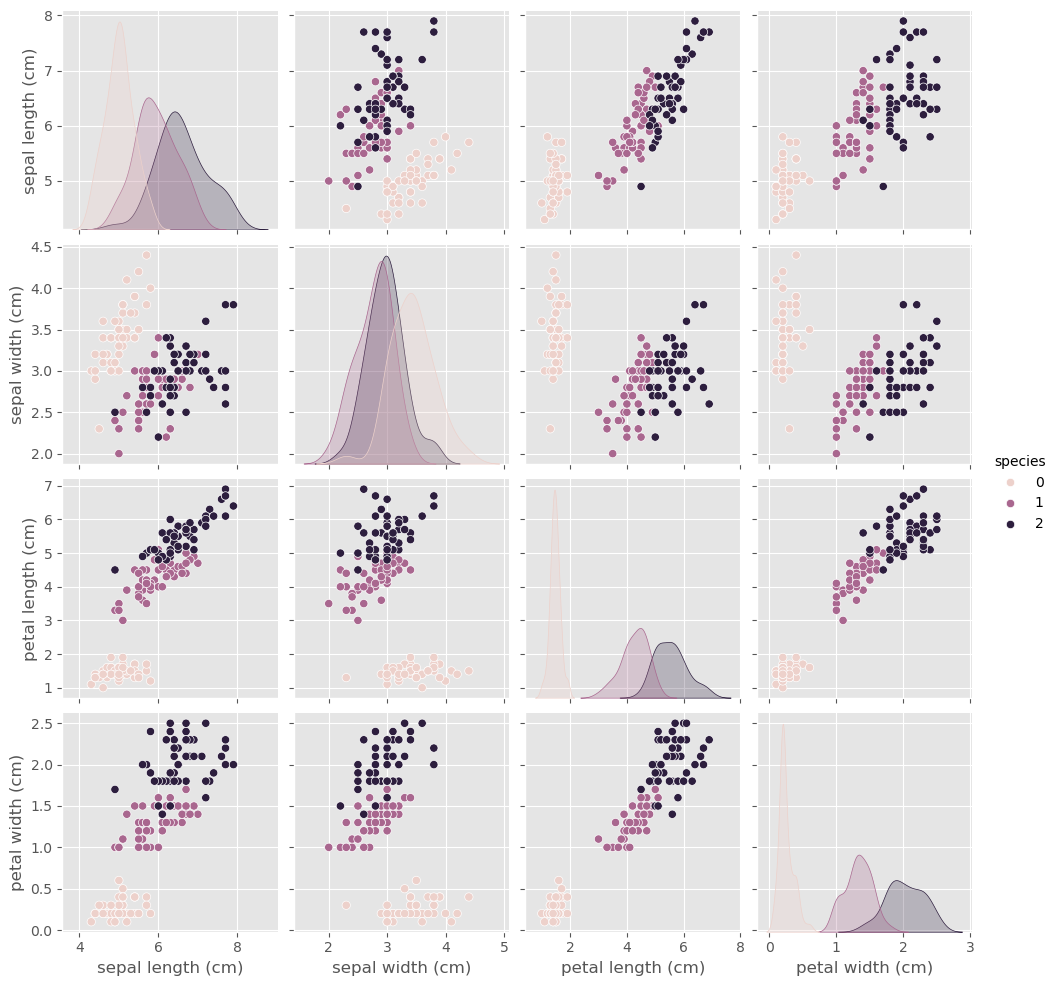

In [99]:
sns.pairplot(df,hue="species")
plt.savefig("images/histogram.png", dpi=300, bbox_inches="tight")
plt.show()
plt.show()

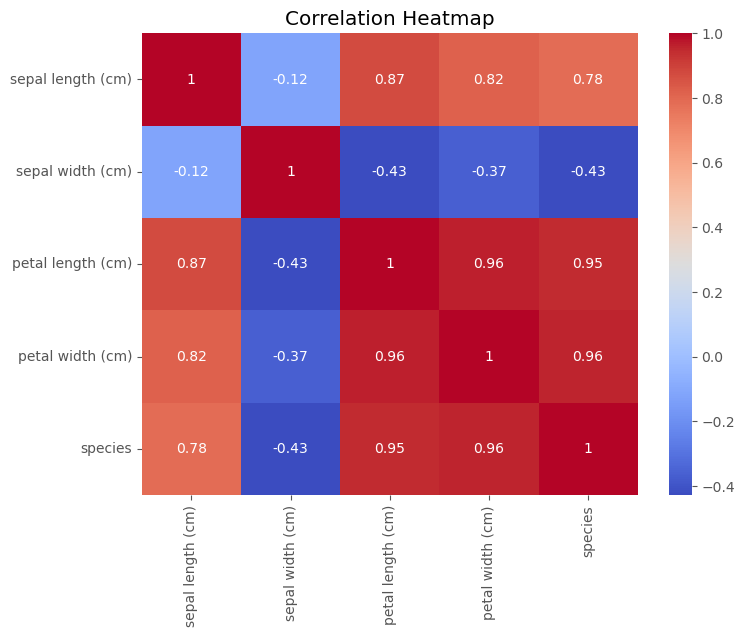

In [100]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
    
)

plt.title("Correlation Heatmap")
plt.savefig("images/heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
plt.show()

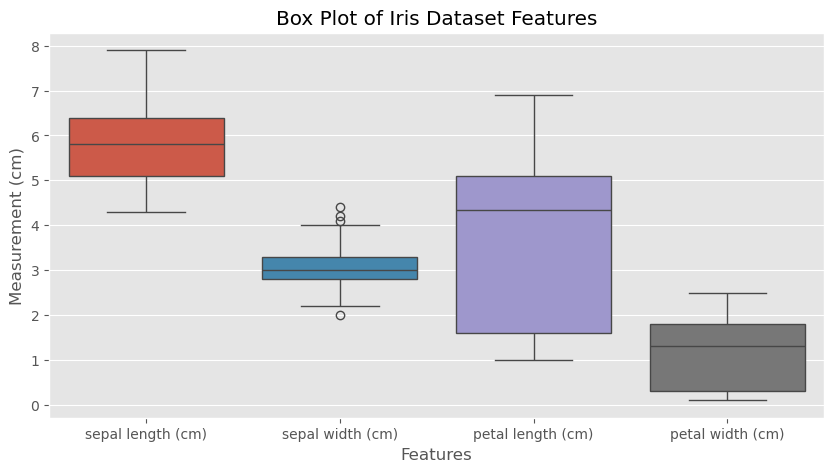

In [101]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df.iloc[:, :4])

plt.title("Box Plot of Iris Dataset Features")
plt.xlabel("Features")
plt.ylabel("Measurement (cm)")

plt.savefig("images/Boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [102]:
## 🤖 Data Preprocessing
X=df.iloc[:,:4]

y=df["species"]

In [103]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [104]:
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)

X_test=scaler.transform(X_test)

In [105]:
## Model 1 - Logistic Regression
lr=LogisticRegression()

lr.fit(X_train,y_train)

pred_lr=lr.predict(X_test)

In [106]:
print(classification_report(y_test,pred_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



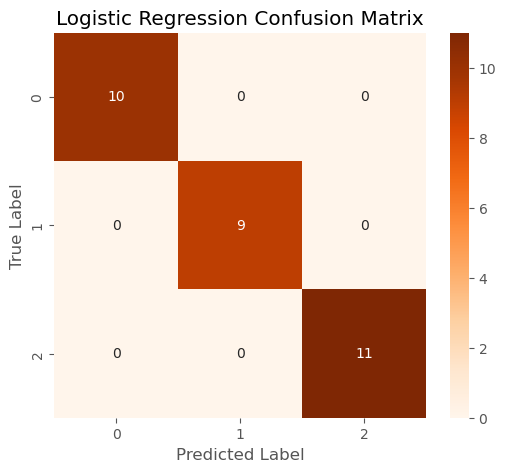

In [107]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix(y_test, pred_lr),
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.savefig("images/Logistic_Regression_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [108]:
## Model 2 - Decision Tree
dt=DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

pred_dt=dt.predict(X_test)


In [109]:
print(classification_report(y_test,pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



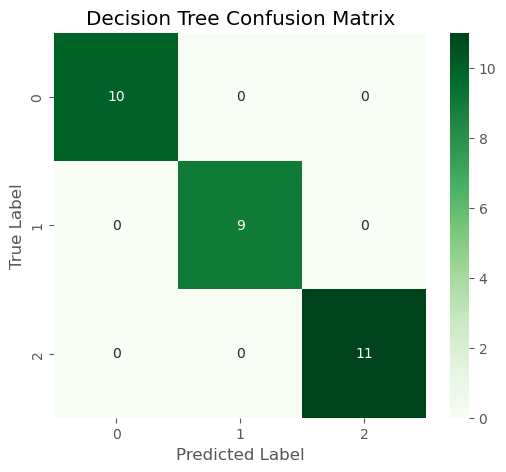

In [110]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix(y_test, pred_dt),
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.savefig("images/Decision_Tree_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [111]:
## Model 3 - Random Forest
rf=RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

pred_rf=rf.predict(X_test)

In [112]:
print(classification_report(y_test,pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



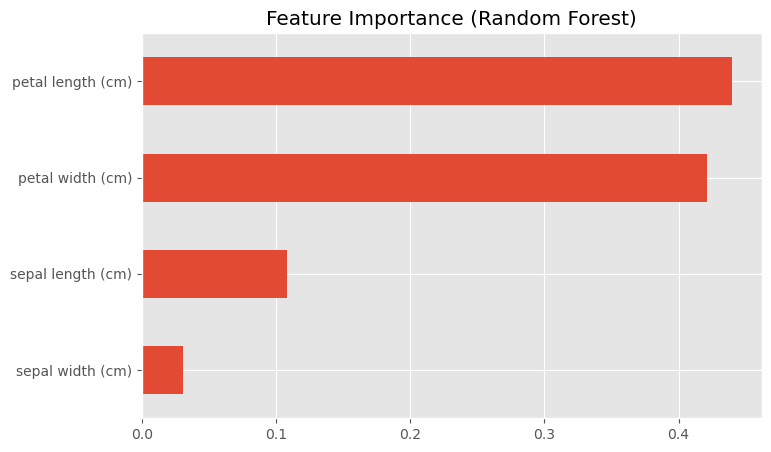

In [113]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Feature Importance (Random Forest)")

plt.savefig("images/important_features_random_forest_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

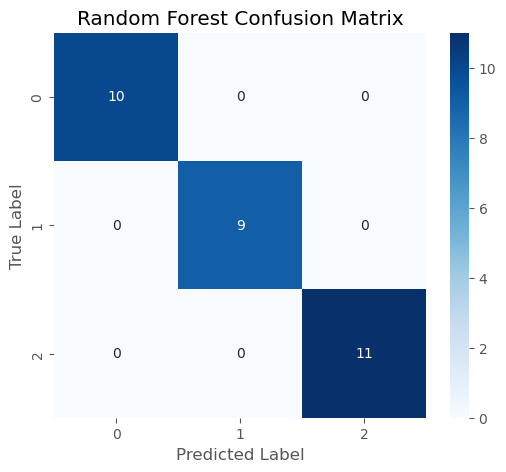

In [114]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix(y_test, pred_rf),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.savefig("images/Random_Forest_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [115]:
# Comparison Table
results=pd.DataFrame({

"Model":[
"Logistic Regression",
"Decision Tree",
"Random Forest"
],

"Accuracy":[

accuracy_score(y_test,pred_lr),

accuracy_score(y_test,pred_dt),

accuracy_score(y_test,pred_rf)

]

})

results

,Model,Accuracy
0,Logistic Regression,1.0
1,Decision Tree,1.0
2,Random Forest,1.0


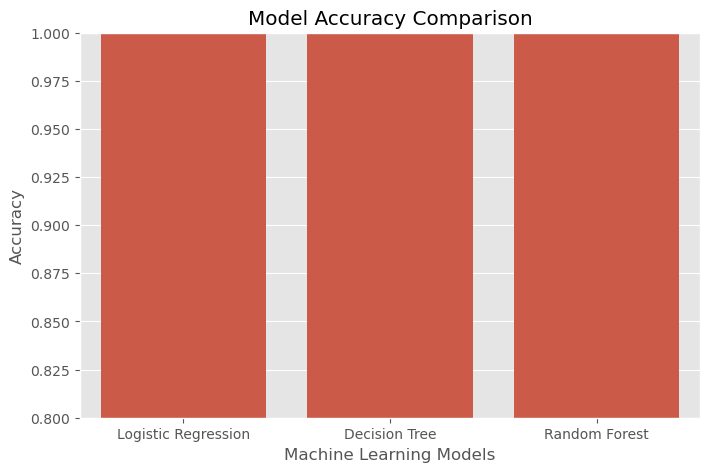

In [116]:
plt.figure(figsize=(8, 5))

sns.barplot(data=results, x="Model", y="Accuracy")

plt.ylim(0.8, 1.0)
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")

plt.savefig("images/Accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

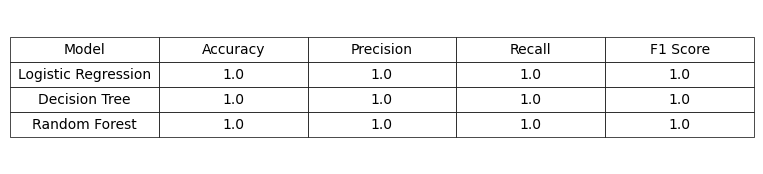

In [121]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_dt),
        accuracy_score(y_test, pred_rf)
    ],

    "Precision": [
        precision_score(y_test, pred_lr, average="weighted"),
        precision_score(y_test, pred_dt, average="weighted"),
        precision_score(y_test, pred_rf, average="weighted")
    ],

    "Recall": [
        recall_score(y_test, pred_lr, average="weighted"),
        recall_score(y_test, pred_dt, average="weighted"),
        recall_score(y_test, pred_rf, average="weighted")
    ],

    "F1 Score": [
        f1_score(y_test, pred_lr, average="weighted"),
        f1_score(y_test, pred_dt, average="weighted"),
        f1_score(y_test, pred_rf, average="weighted")
    ]
})

results = results.round(4)

results

plt.figure(figsize=(8, 2))

plt.axis("off")

table = plt.table(
    cellText=results.values,
    colLabels=results.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.savefig("images/Model_Comparison_Table.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Decision Boundary Visualization

This visualization demonstrates how the Logistic Regression model separates
the three Iris flower species using two important features:
Petal Length and Petal Width.



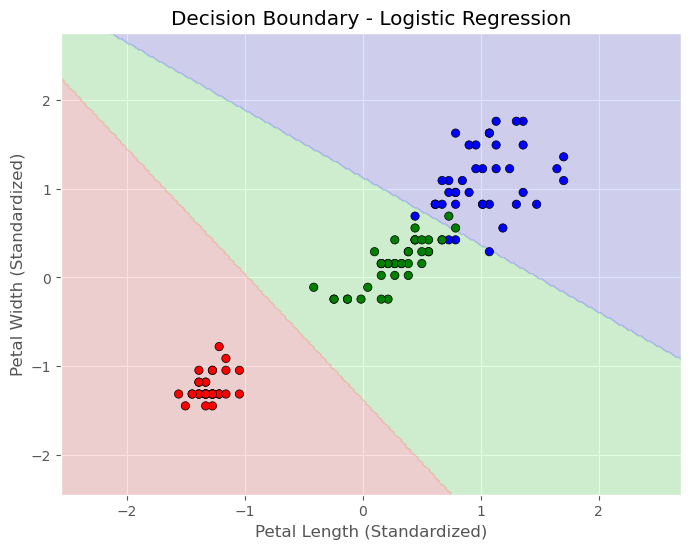

In [118]:
print("""Decision Boundary Visualization

This visualization demonstrates how the Logistic Regression model separates
the three Iris flower species using two important features:
Petal Length and Petal Width.
""")

# Select only Petal Length and Petal Width
X_boundary = df.iloc[:, [2, 3]]
y_boundary = df["species"]

# Train-test split
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_boundary,
    y_boundary,
    test_size=0.2,
    random_state=42
)

# Standardize features
scaler = StandardScaler()
X_train_b = scaler.fit_transform(X_train_b)
X_test_b = scaler.transform(X_test_b)

# Train Logistic Regression
model = LogisticRegression(max_iter=200)
model.fit(X_train_b, y_train_b)

# Create mesh grid
x1_min, x1_max = X_train_b[:, 0].min() - 1, X_train_b[:, 0].max() + 1
x2_min, x2_max = X_train_b[:, 1].min() - 1, X_train_b[:, 1].max() + 1

xx1, xx2 = np.meshgrid(
    np.arange(x1_min, x1_max, 0.02),
    np.arange(x2_min, x2_max, 0.02)
)

# Predict every point in the grid
Z = model.predict(np.c_[xx1.ravel(), xx2.ravel()])
Z = Z.reshape(xx1.shape)

# Plot
plt.figure(figsize=(8,6))

plt.contourf(
    xx1,
    xx2,
    Z,
    alpha=0.3,
    cmap=ListedColormap(["#FF9999", "#99FF99", "#9999FF"])
)

plt.scatter(
    X_train_b[:,0],
    X_train_b[:,1],
    c=y_train_b,
    edgecolor="black",
    cmap=ListedColormap(["red","green","blue"])
)

plt.title("Decision Boundary - Logistic Regression")
plt.xlabel("Petal Length (Standardized)")
plt.ylabel("Petal Width (Standardized)")

# Save BEFORE showing
plt.savefig("images/Decision_boundary.png", dpi=300, bbox_inches="tight")

plt.show()

In [119]:
print("""Key Findings

- All three models achieved excellent classification performance.
- Random Forest produced the highest overall accuracy.
- Petal length and petal width were the most influential features.
- The Iris dataset is highly separable, making it suitable for classification algorithms.""")

Key Findings

- All three models achieved excellent classification performance.
- Random Forest produced the highest overall accuracy.
- Petal length and petal width were the most influential features.
- The Iris dataset is highly separable, making it suitable for classification algorithms.


In [120]:
print("""
Conclusion

In this project, three machine learning classification models—Logistic Regression, Decision Tree, and Random Forest—were trained and evaluated using 
the Iris dataset.

The dataset was explored through Exploratory Data Analysis (EDA), followed by data preprocessing, train-test splitting, and feature scaling.

All three models achieved perfect performance on the test dataset, with an Accuracy, Precision, Recall, and F1-Score of 1.00. This indicates that 
the Iris dataset is well-structured and can be classified effectively using these algorithms.

This project demonstrates a complete machine learning workflow, including data exploration, preprocessing, model training, evaluation, comparison,
and visualization.
""")


Conclusion

In this project, three machine learning classification models—Logistic Regression, Decision Tree, and Random Forest—were trained and evaluated using 
the Iris dataset.

The dataset was explored through Exploratory Data Analysis (EDA), followed by data preprocessing, train-test splitting, and feature scaling.

All three models achieved perfect performance on the test dataset, with an Accuracy, Precision, Recall, and F1-Score of 1.00. This indicates that 
the Iris dataset is well-structured and can be classified effectively using these algorithms.

This project demonstrates a complete machine learning workflow, including data exploration, preprocessing, model training, evaluation, comparison,
and visualization.

